<a href="https://colab.research.google.com/github/amruthams8dchs-spec/Visual-Cryptography/blob/main/Visual_Cryptography.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving COOPBL.TTF to COOPBL.TTF


{'COOPBL.TTF': b'\x00\x01\x00\x00\x00\x10\x01\x00\x00\x04\x00\x00DSIG\x93I\xe8#\x00\x01%\x1c\x00\x00\x14\xe8OS/2y\x89\x98\xb9\x00\x00\x01\x88\x00\x00\x00Vcmape\xff\xa9v\x00\x00\x07\x88\x00\x00\x03.cvt }\xd8\x92\xd3\x00\x00\x16L\x00\x00\x02.fpgmw\xa0\x1a\x00\x00\x00\x11\x00\x00\x00\x05Kglyf\x83JA\x9e\x00\x004t\x00\x00\xd6\xachdmx\xf8\x9d\x85m\x00\x00\x1cl\x00\x00\x18\x08head\xc4\xfeK+\x00\x00\x01\x0c\x00\x00\x006hhea\x0f\xe4\x07\xdb\x00\x00\x01D\x00\x00\x00$hmtx\xbbK.\xbb\x00\x00\x18|\x00\x00\x03\xf0kern\xf9\x19\xfeR\x00\x01\r\xbc\x00\x00\x17^loca\x8cqVp\x00\x00\n\xb8\x00\x00\x01\xfamaxp\x04\x1f\x02\x9d\x00\x00\x01h\x00\x00\x00 name\xf0$p\xd9\x00\x00\x01\xe0\x00\x00\x05\xa8post\xa2\x1c\x87\x84\x00\x01\x0b \x00\x00\x02\x9cprep\xf4F\xa3\xd0\x00\x00\x0c\xb4\x00\x00\x04K\x00\x01\x00\x00\x00\x01\x82\x8fI\xef\xee\t_\x0f<\xf5\x00\x0b\x08\x00\x00\x00\x00\x00\xa9v\x96\xeb\x00\x00\x00\x00\xb3\xde\xe7]\xfe\xa6\xfd\xfe\t\xe3\x07X\x00\x00\x00\t\x00\x02\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x07X\xf

In [ ]:
from PIL import Image, ImageDraw, ImageFont
img = Image.new("RGB", (100,100), "white")
draw = ImageDraw.Draw(img)
font = ImageFont.truetype("COOPBL.TTF",17)
draw.text((17,42), "SECRET", fill="black",font = font)
img.save("hello.png")
img.show()

 Saved: share1.png, share2.png, overlay.png


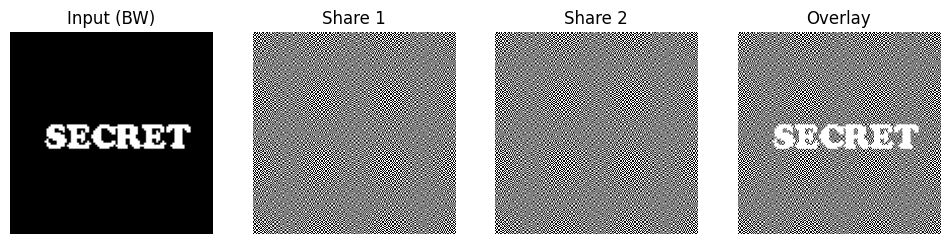

In [ ]:
from PIL import Image
import numpy as np
import sys
import os
import random
import matplotlib.pyplot as plt

def binarize(img, threshold=128):
    """Convert image to pure black & white (0 or 255)."""
    gray = img.convert('L')
    arr = np.array(gray)
    bw = (arr < threshold).astype(np.uint8) * 255
    return Image.fromarray(bw)

def make_shares(bw_img):
    """Create two shares from a BW image using visual cryptography rules."""
    arr = np.array(bw_img) // 255  # 0 for white, 1 for black
    h, w = arr.shape

    # Each pixel becomes a 2x2 block in each share
    share1 = np.zeros((h*2, w*2), dtype=np.uint8)
    share2 = np.zeros((h*2, w*2), dtype=np.uint8)

    # Two base patterns (complementary)
    patterns = [
        np.array([[1,0],[0,1]], dtype=np.uint8),  # diagonal
        np.array([[0,1],[1,0]], dtype=np.uint8)   # opposite diagonal
    ]

    for i in range(h):
        for j in range(w):
            pixel = arr[i, j]  # 0 white, 1 black
            p = random.choice(patterns)
            q = p.copy() if pixel == 0 else 1 - p
            share1[i*2:(i+1)*2, j*2:(j+1)*2] = p * 255
            share2[i*2:(i+1)*2, j*2:(j+1)*2] = q * 255

    return Image.fromarray(share1), Image.fromarray(share2)

def overlay(shareA, shareB):
    """Overlay two shares by taking minimum (black dominates)."""
    a = np.array(shareA.convert('L')) // 255
    b = np.array(shareB.convert('L')) // 255
    over = np.minimum(a + b, 1) * 255
    return Image.fromarray(over.astype(np.uint8))

def main(path):
    if not os.path.exists(path):
        print("Input file not found:", path)
        return
    inp = Image.open(path)
    bw = binarize(inp)
    s1, s2 = make_shares(bw)
    ov = overlay(s1, s2)

    s1.save('share1.png')
    s2.save('share2.png')
    ov.save('overlay.png')
    print(" Saved: share1.png, share2.png, overlay.png")

    # Display all images side by side
    titles = ['Input (BW)', 'Share 1', 'Share 2', 'Overlay']
    imgs = [bw, s1, s2, ov]

    plt.figure(figsize=(12,4))
    for i in range(4):
        plt.subplot(1,4,i+1)
        plt.imshow(imgs[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

#  Default run for Colab or Jupyter
if __name__ == '__main__':
    main('hello.png')